# ANALISIS NUMERIK GERAI DONAT

**Tugas:** Regresi dan Pencarian Akar  
**Dataset:** `sintesis_data_donat_harian.csv` dari GitHub

### Tujuan
1. Membuat plot jumlah penjualan vs revenue untuk lima gerai.
2. Menerapkan regresi untuk mengetahui hubungan volume penjualan dengan revenue.
3. Menentukan Break-Even Point (BEP) masing-masing gerai menggunakan pencarian akar.


## Instruksi Tugas

Tugas memiliki tiga bagian utama:

- **30% — Plot:** membuat plot `jumlah penjualan vs revenue` untuk kelima gerai.
- **30% — Regresi:** menerapkan regresi untuk melihat bentuk tren revenue berdasarkan volume penjualan. Model dapat berupa linear, polynomial, eksponen, atau model lain yang sesuai.
- **40% — Pencarian akar:** mencari jumlah volume penjualan yang menghasilkan **break-even point**, yaitu kondisi laba/rugi = 0, berdasarkan model regresi.

Dataset yang digunakan adalah dataset yang sudah diberikan pada soal. Jadi data tidak perlu dibuat atau diganti.


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress
from scipy.optimize import brentq

print("Library berhasil diimport.")


Library berhasil diimport.


## 2. Mengambil Dataset

Dataset diambil langsung dari repository GitHub yang diberikan pada soal.


In [2]:
url = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"

df = pd.read_csv(url)

df.head()


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


## 3. Pemeriksaan Dataset

In [3]:
print("Ukuran data:", df.shape)
print("\nKolom:")
print(df.columns.tolist())

print("\nJumlah data per gerai:")
print(df["Gerai"].value_counts())

print("\nMissing value:")
print(df.isnull().sum())


Ukuran data: (450, 8)

Kolom:
['Tanggal', 'Gerai', 'Harga Jual (Rp)', 'Jumlah Terjual (Unit)', 'Pendapatan Kotor (Rp)', 'Biaya Variabel (Rp)', 'Fixed Cost Harian (Rp)', 'Balance (Rp)']

Jumlah data per gerai:
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64

Missing value:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64


## 4. Plot Jumlah Penjualan vs Revenue

Sumbu-x menunjukkan jumlah unit donat yang terjual dalam satu hari, sedangkan sumbu-y menunjukkan revenue atau pendapatan kotor harian.


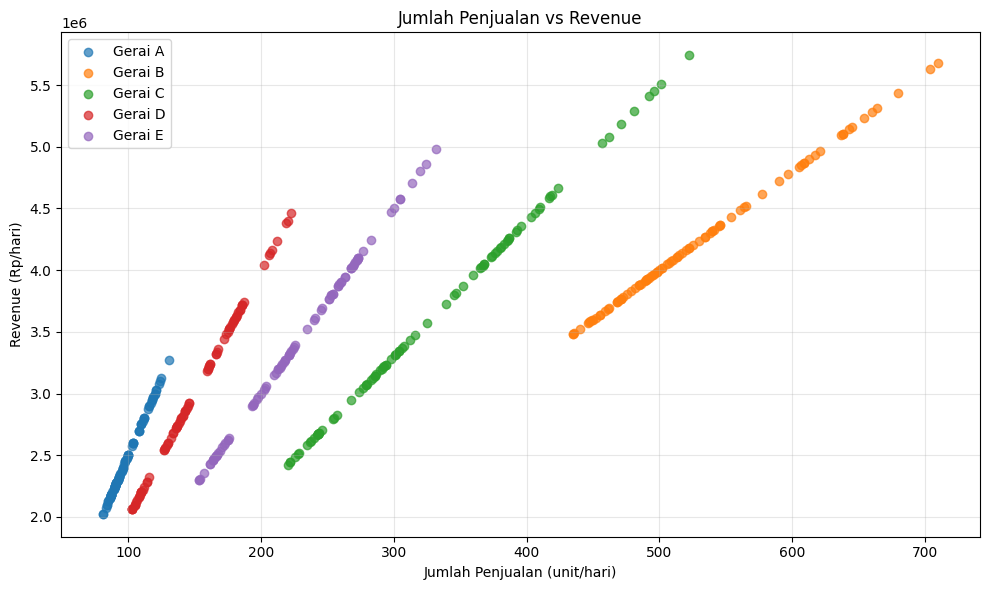

In [4]:
plt.figure(figsize=(10, 6))

for gerai, data in df.groupby("Gerai"):
    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai,
        alpha=0.7
    )

plt.title("Jumlah Penjualan vs Revenue")
plt.xlabel("Jumlah Penjualan (unit/hari)")
plt.ylabel("Revenue (Rp/hari)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretasi Plot

Berdasarkan struktur data, setiap gerai memiliki harga jual yang tetap. Oleh karena itu, revenue meningkat secara proporsional terhadap jumlah unit yang terjual. Pola titik pada masing-masing gerai membentuk hubungan linear.


## 5. Regresi Linear Revenue terhadap Volume Penjualan

Model yang digunakan:

**Revenue = a + bX**

dengan:
- `X` = jumlah penjualan per hari
- `a` = intercept
- `b` = slope
- `R²` = koefisien determinasi

Regresi linear digunakan karena hubungan pada data bersifat linear.


In [5]:
hasil_regresi = []

for gerai, data in df.groupby("Gerai"):
    x = data["Jumlah Terjual (Unit)"]
    y = data["Pendapatan Kotor (Rp)"]

    reg = linregress(x, y)

    hasil_regresi.append({
        "Gerai": gerai,
        "Intercept": reg.intercept,
        "Slope": reg.slope,
        "R2": reg.rvalue ** 2
    })

hasil_regresi = pd.DataFrame(hasil_regresi)

hasil_regresi


,Gerai,Intercept,Slope,R2
0,Gerai A,-4.656613e-10,25000.0,1.0
1,Gerai B,9.313226e-10,8000.0,1.0
2,Gerai C,4.656613e-10,11000.0,1.0
3,Gerai D,-1.862645e-09,20000.0,1.0
4,Gerai E,2.793968e-09,15000.0,1.0


In [6]:
for _, row in hasil_regresi.iterrows():
    print(
        f"{row['Gerai']}: "
        f"Revenue = {row['Intercept']:.2f} + "
        f"{row['Slope']:.2f}X, "
        f"R² = {row['R2']:.6f}"
    )


Gerai A: Revenue = -0.00 + 25000.00X, R² = 1.000000
Gerai B: Revenue = 0.00 + 8000.00X, R² = 1.000000
Gerai C: Revenue = 0.00 + 11000.00X, R² = 1.000000
Gerai D: Revenue = -0.00 + 20000.00X, R² = 1.000000
Gerai E: Revenue = 0.00 + 15000.00X, R² = 1.000000


### Interpretasi Regresi Revenue

Hasil regresi menunjukkan bahwa hubungan antara jumlah penjualan dan revenue sangat kuat. Nilai slope menunjukkan tambahan revenue yang diperoleh dari setiap tambahan satu unit donat yang terjual. Karena harga jual setiap gerai tetap, slope regresi sesuai dengan harga jual masing-masing gerai.


## 6. Visualisasi Garis Regresi Revenue

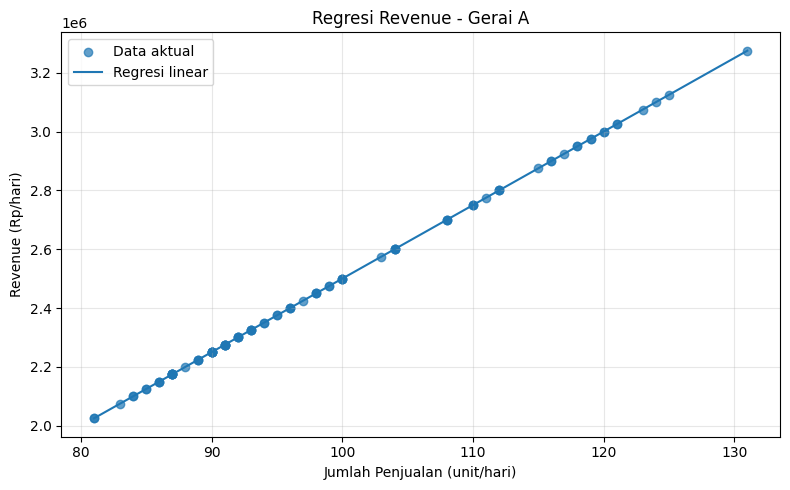

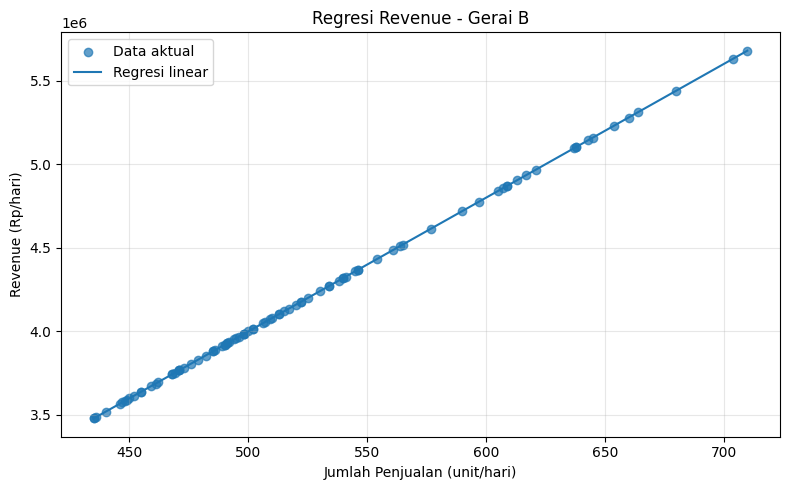

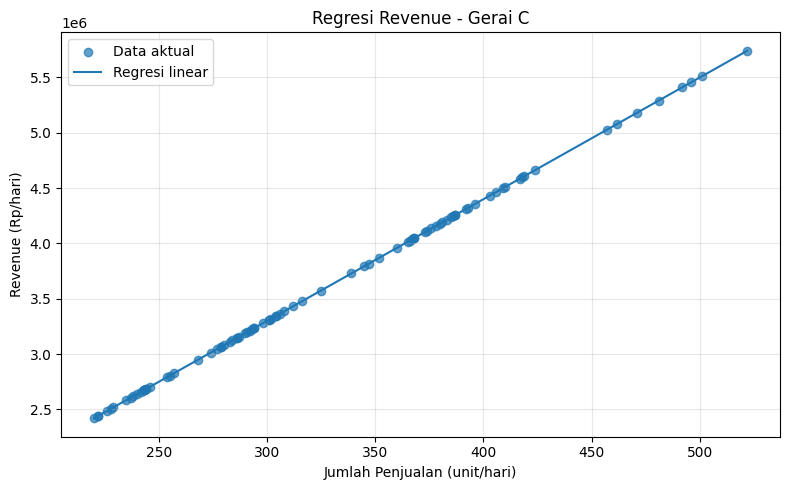

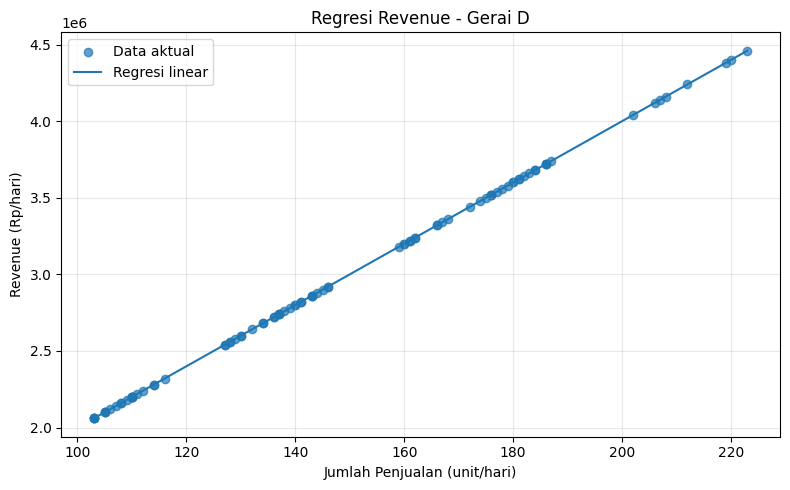

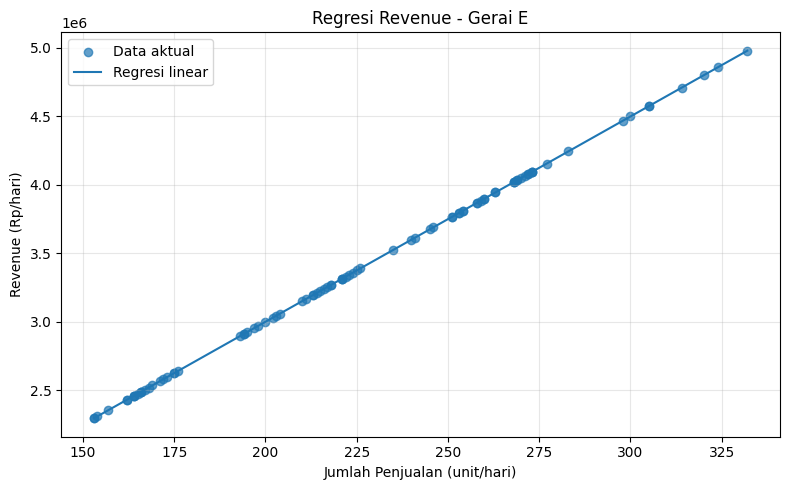

In [7]:
for gerai, data in df.groupby("Gerai"):
    row = hasil_regresi[hasil_regresi["Gerai"] == gerai].iloc[0]

    x = data["Jumlah Terjual (Unit)"]
    y = data["Pendapatan Kotor (Rp)"]

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = row["Intercept"] + row["Slope"] * x_line

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.7, label="Data aktual")
    plt.plot(x_line, y_line, label="Regresi linear")

    plt.title(f"Regresi Revenue - {gerai}")
    plt.xlabel("Jumlah Penjualan (unit/hari)")
    plt.ylabel("Revenue (Rp/hari)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7. Regresi Balance terhadap Volume Penjualan

Untuk mencari BEP, regresi revenue saja tidak cukup. BEP terjadi ketika **laba/rugi (Balance) = 0**.

Karena itu digunakan model:

**Balance = a + bX**

Kemudian akar fungsi tersebut dicari:

**f(X) = a + bX = 0**

Nilai X yang diperoleh merupakan volume penjualan pada titik impas.


In [8]:
hasil_balance = []

for gerai, data in df.groupby("Gerai"):
    x = data["Jumlah Terjual (Unit)"]
    y = data["Balance (Rp)"]

    reg = linregress(x, y)

    hasil_balance.append({
        "Gerai": gerai,
        "Intercept Balance": reg.intercept,
        "Slope Balance": reg.slope,
        "R2 Balance": reg.rvalue ** 2
    })

hasil_balance = pd.DataFrame(hasil_balance)

hasil_balance


,Gerai,Intercept Balance,Slope Balance,R2 Balance
0,Gerai A,-1683333.0,16500.0,1.0
1,Gerai B,-733333.0,3840.0,1.0
2,Gerai C,-1733333.0,6160.0,1.0
3,Gerai D,-2666666.0,12800.0,1.0
4,Gerai E,-800000.0,8700.0,1.0


In [9]:
for _, row in hasil_balance.iterrows():
    print(
        f"{row['Gerai']}: "
        f"Balance = {row['Intercept Balance']:.2f} + "
        f"{row['Slope Balance']:.2f}X, "
        f"R² = {row['R2 Balance']:.6f}"
    )


Gerai A: Balance = -1683333.00 + 16500.00X, R² = 1.000000
Gerai B: Balance = -733333.00 + 3840.00X, R² = 1.000000
Gerai C: Balance = -1733333.00 + 6160.00X, R² = 1.000000
Gerai D: Balance = -2666666.00 + 12800.00X, R² = 1.000000
Gerai E: Balance = -800000.00 + 8700.00X, R² = 1.000000


## 8. Pencarian Akar dengan Metode Brent

Metode `brentq` digunakan untuk mencari akar numerik dari fungsi balance.

Interval pencarian ditetapkan dari `0` sampai `1000` unit karena seluruh BEP kelima gerai berada dalam interval tersebut.


In [10]:
hasil_bep = []

for _, row in hasil_balance.iterrows():

    a = row["Intercept Balance"]
    b = row["Slope Balance"]

    def f(x):
        return a + b * x

    bep = brentq(f, 0, 1000)

    hasil_bep.append({
        "Gerai": row["Gerai"],
        "BEP (unit)": bep,
        "BEP Minimum (unit)": np.ceil(bep)
    })

hasil_bep = pd.DataFrame(hasil_bep)

hasil_bep


,Gerai,BEP (unit),BEP Minimum (unit)
0,Gerai A,102.020182,103.0
1,Gerai B,190.972135,191.0
2,Gerai C,281.385227,282.0
3,Gerai D,208.333281,209.0
4,Gerai E,91.954023,92.0


## 9. Hasil Break-Even Point

In [11]:
hasil_bep["BEP Minimum (unit)"] = hasil_bep["BEP Minimum (unit)"].astype(int)

hasil_bep


,Gerai,BEP (unit),BEP Minimum (unit)
0,Gerai A,102.020182,103
1,Gerai B,190.972135,191
2,Gerai C,281.385227,282
3,Gerai D,208.333281,209
4,Gerai E,91.954023,92


### Interpretasi BEP

BEP menunjukkan jumlah minimum unit yang perlu terjual agar balance mencapai kondisi impas. Karena jumlah donat harus berupa bilangan bulat, hasil BEP numerik dibulatkan ke atas untuk mendapatkan volume penjualan minimum dalam satuan unit.


## 10. Visualisasi Regresi Balance dan BEP

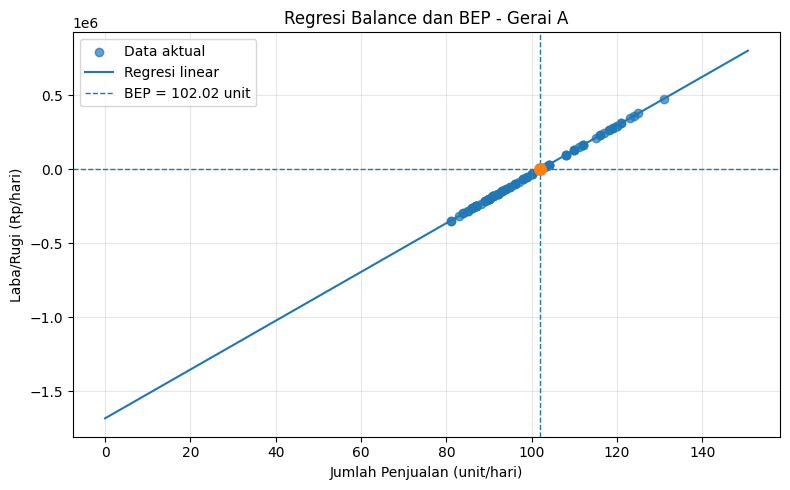

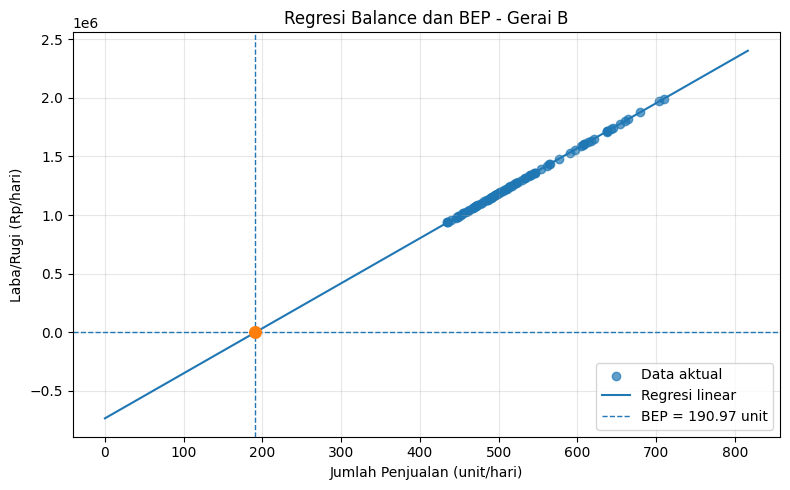

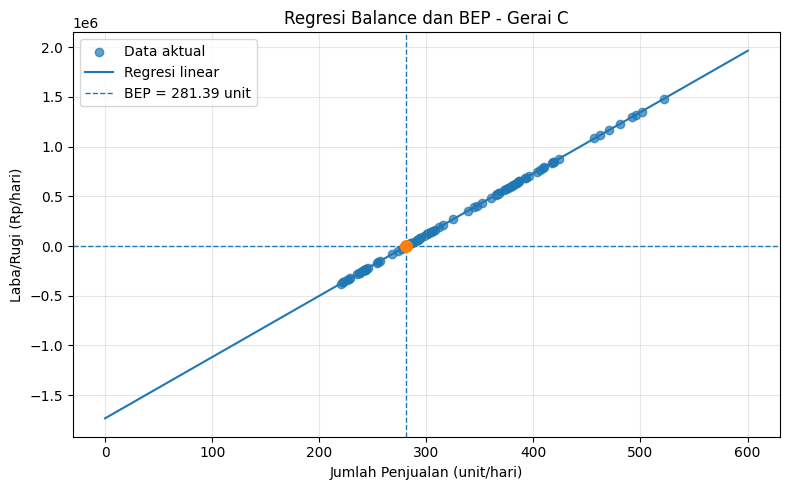

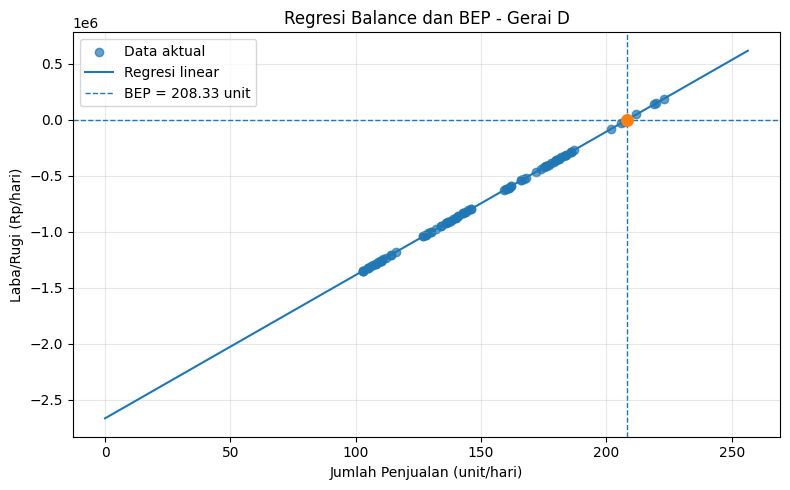

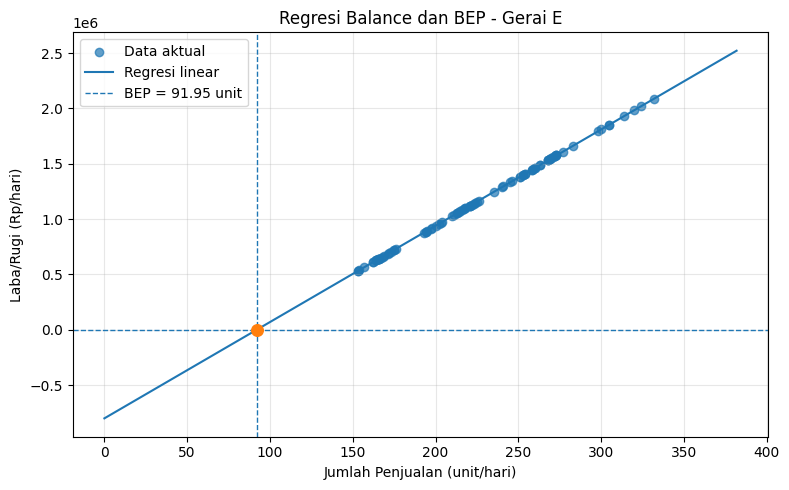

In [12]:
for gerai, data in df.groupby("Gerai"):

    row = hasil_balance[hasil_balance["Gerai"] == gerai].iloc[0]
    bep = hasil_bep[hasil_bep["Gerai"] == gerai]["BEP (unit)"].iloc[0]

    x = data["Jumlah Terjual (Unit)"]
    y = data["Balance (Rp)"]

    x_line = np.linspace(0, max(x.max(), bep) * 1.15, 200)
    y_line = row["Intercept Balance"] + row["Slope Balance"] * x_line

    plt.figure(figsize=(8, 5))

    plt.scatter(x, y, alpha=0.7, label="Data aktual")
    plt.plot(x_line, y_line, label="Regresi linear")

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(
        bep,
        linestyle="--",
        linewidth=1,
        label=f"BEP = {bep:.2f} unit"
    )

    plt.scatter([bep], [0], s=70, zorder=5)

    plt.title(f"Regresi Balance dan BEP - {gerai}")
    plt.xlabel("Jumlah Penjualan (unit/hari)")
    plt.ylabel("Laba/Rugi (Rp/hari)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 11. Ringkasan Hasil

In [13]:
ringkasan = hasil_regresi.merge(
    hasil_balance,
    on="Gerai"
).merge(
    hasil_bep,
    on="Gerai"
)

ringkasan


,Gerai,Intercept,Slope,R2,Intercept Balance,Slope Balance,R2 Balance,BEP (unit),BEP Minimum (unit)
0,Gerai A,-4.656613e-10,25000.0,1.0,-1683333.0,16500.0,1.0,102.020182,103
1,Gerai B,9.313226e-10,8000.0,1.0,-733333.0,3840.0,1.0,190.972135,191
2,Gerai C,4.656613e-10,11000.0,1.0,-1733333.0,6160.0,1.0,281.385227,282
3,Gerai D,-1.862645e-09,20000.0,1.0,-2666666.0,12800.0,1.0,208.333281,209
4,Gerai E,2.793968e-09,15000.0,1.0,-800000.0,8700.0,1.0,91.954023,92


## 12. Kesimpulan

Berdasarkan hasil analisis, hubungan antara jumlah penjualan dan revenue pada kelima gerai dapat dimodelkan menggunakan regresi linear. Hal tersebut sesuai dengan struktur data karena setiap gerai memiliki harga jual per unit yang tetap.

Untuk menentukan Break-Even Point, digunakan regresi antara jumlah penjualan dan balance (laba/rugi). Selanjutnya, akar dari fungsi regresi balance dicari menggunakan metode Brent dengan kondisi `Balance = 0`.

Hasil BEP menunjukkan volume penjualan yang diperlukan masing-masing gerai agar mencapai titik impas. Karena volume penjualan merupakan bilangan bulat, hasil BEP numerik dibulatkan ke atas menjadi volume minimum unit yang perlu terjual.
